# ex7 ANN Regression

In [1]:
import torch
import torch.nn as nn
import torch.optim as opt
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


## make dataset

In [2]:
N = 1000
X = np.random.random((N,2))*6-3
y = np.cos(2*X[:,0])+np.cos(3*X[:,1])

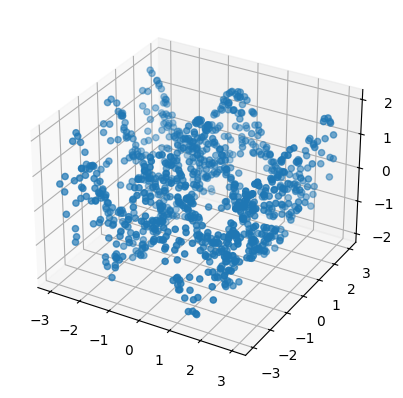

In [3]:
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.scatter(X[:,0],X[:,1],y)

In [4]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=33)
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)
y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [5]:
model = nn.Sequential(
    nn.Linear(2,128),
    nn.ReLU(),
    nn.Linear(128,256),
    nn.ReLU(),
    nn.Linear(256,128),
    nn.ReLU(),
    nn.Linear(128,1)
)
model.to(device=device)

criterion = nn.MSELoss()
criterion.to(device)
optimizer = opt.Adam(model.parameters(),lr=0.01)

In [6]:
X_train = torch.from_numpy(X_train.astype(np.float32))
X_test = torch.from_numpy(X_test.astype(np.float32))
y_train = torch.from_numpy(y_train.astype(np.float32))
y_test = torch.from_numpy(y_test.astype(np.float32))

In [7]:
train_losses = []
test_losses = []

epochs = 800

for epoch in range(1,epochs+1):
    optimizer.zero_grad()
    X_train,y_train = X_train.to(device),y_train.to(device)
    
    y_hat = model(X_train)
    loss = criterion(y_hat,y_train)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    #test
    X_test,y_test = X_test.to(device),y_test.to(device)
    y_hat = model(X_test)
    loss = criterion(y_hat,y_test)
    test_losses.append(loss.item())
    print(f'{epoch}/{epochs} train loss {train_losses[-1]} test loss {test_losses[-1]}')

1/800 train loss 0.9432684779167175 test loss 2.1310555934906006
2/800 train loss 2.326092004776001 test loss 2.0341429710388184
3/800 train loss 1.873181939125061 test loss 1.1409177780151367
4/800 train loss 1.0703881978988647 test loss 0.972489595413208
5/800 train loss 0.9428688883781433 test loss 0.9574661254882812
6/800 train loss 0.9435141086578369 test loss 0.955403208732605
7/800 train loss 0.9481211304664612 test loss 0.9518844485282898
8/800 train loss 0.9453395009040833 test loss 0.9490477442741394
9/800 train loss 0.9403376579284668 test loss 0.9460351467132568
10/800 train loss 0.9352866411209106 test loss 0.9443252086639404
11/800 train loss 0.9312968850135803 test loss 0.9385173320770264
12/800 train loss 0.9268944263458252 test loss 0.9280534386634827
13/800 train loss 0.9205836653709412 test loss 0.9144846200942993
14/800 train loss 0.9129641056060791 test loss 0.9001980423927307
15/800 train loss 0.9039472341537476 test loss 0.8847769498825073
16/800 train loss 0.893

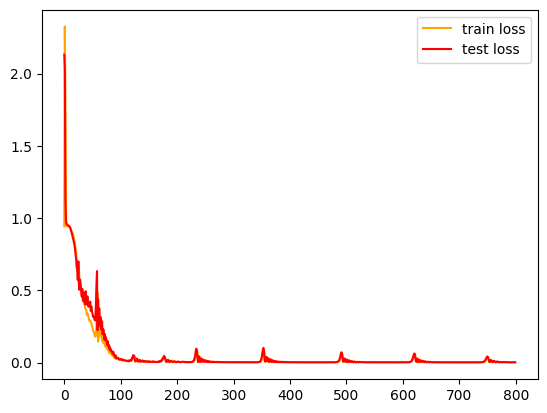

In [8]:
ticks = [x for x in range(len(train_losses))]

plt.plot(ticks,train_losses,label='train loss',color='orange')
plt.plot(ticks,test_losses,label='test loss',color='red')
plt.legend()

# plotting in 3d


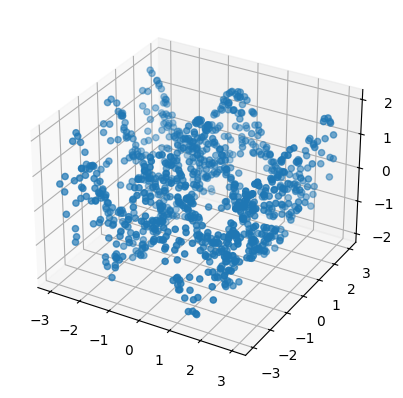

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.scatter(X[:,0],X[:,1],y)

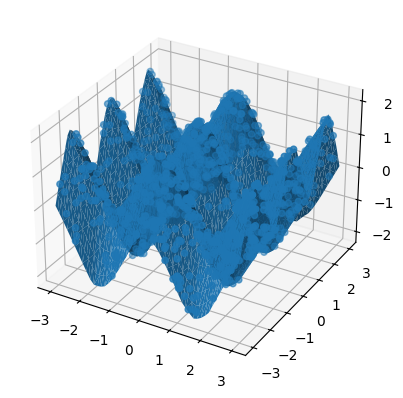

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.scatter(X[:,0],X[:,1],y)
with torch.no_grad():
    line = np.linspace(-3,3,50)
    xx,yy = np.meshgrid(line,line)
    Xgrid = np.vstack((xx.flatten(),yy.flatten())).T
    Xgrid_torch = torch.from_numpy(Xgrid.astype(np.float32))
    Xgrid_torch = Xgrid_torch.to(device)
    y_hat = model(Xgrid_torch).cpu().numpy().flatten()
    ax.plot_trisurf(Xgrid[:,0],Xgrid[:,1],y_hat,linewidth=0.2,antialiased = True)
    plt.show()

can it generalize our periodic function

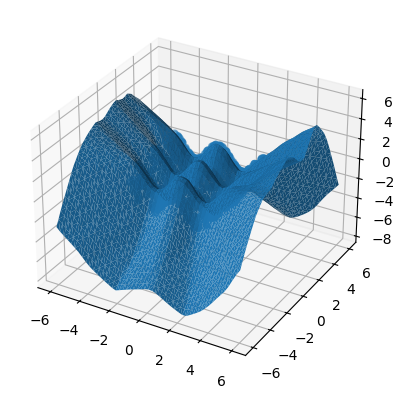

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.scatter(X[:,0],X[:,1],y)
with torch.no_grad():
    line = np.linspace(-6,6,50)
    xx,yy = np.meshgrid(line,line)
    Xgrid = np.vstack((xx.flatten(),yy.flatten())).T
    Xgrid_torch = torch.from_numpy(Xgrid.astype(np.float32))
    Xgrid_torch = Xgrid_torch.to(device)
    y_hat = model(Xgrid_torch).cpu().numpy().flatten()
    ax.plot_trisurf(Xgrid[:,0],Xgrid[:,1],y_hat,linewidth=0.2,antialiased = True)
    plt.show()